# Resultados Técnicos: Modelo de Pronóstico de Ventas Retail

Este notebook evalúa los artefactos generados por el pipeline de modelado en Kedro. **No entrena ni modifica el modelo.**

Complementa el notebook de negocio (`02_business_results.ipynb`) con foco en:
- Validación técnica del diseño de la solución
- Métricas globales y por segmento (con todas las métricas)
- Análisis de errores sistemáticos
- Importancia de variables (gain y split, encoded y original)
- Verificación de prevención de leakage

No repite el EDA de `01_eda_problem_framing.ipynb` ni la narrativa ejecutiva de `02_business_results.ipynb`.

In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import yaml
from IPython.display import Markdown, display

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 11

def _find_project_root(start: Path) -> Path:
    for p in [start] + list(start.parents):
        if (p / "pyproject.toml").exists():
            return p
    return start

PROJECT_ROOT = _find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / "data"
CONF_DIR = PROJECT_ROOT / "conf" / "base"

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/gamaliel.torres/Proyectos/reto_tecnico_WM/retowm


In [2]:
def fmt_num(v, decimals=2):
    return f"{v:,.{decimals}f}"

def fmt_pct(v, decimals=2):
    return f"{v * 100:.{decimals}f}%"

def safe_div(num, den):
    return float(num / den) if den != 0 else 0.0

def _pivot_segment(sm, seg_col):
    """Pivot baseline vs lightgbm for a segment column."""
    sub = sm[sm["segment_column"] == seg_col].copy()
    b = sub[sub["model"] == "baseline_lag_7"].set_index("segment_value")[["n_rows","mae","rmse","smape","relative_mae"]].add_prefix("b_")
    l = sub[sub["model"] == "lightgbm"].set_index("segment_value")[["mae","rmse","smape","relative_mae"]].add_prefix("l_")
    df = b.join(l, how="inner").reset_index()
    df["mae_impr_pct"]   = df.apply(lambda r: safe_div(r["b_mae"]   - r["l_mae"],   r["b_mae"])   * 100, axis=1)
    df["rmse_impr_pct"]  = df.apply(lambda r: safe_div(r["b_rmse"]  - r["l_rmse"],  r["b_rmse"])  * 100, axis=1)
    df["smape_impr_pct"] = df.apply(lambda r: safe_div(r["b_smape"] - r["l_smape"], r["b_smape"]) * 100, axis=1)
    return df.sort_values("mae_impr_pct", ascending=False).reset_index(drop=True)

In [3]:
PATHS = {
    "model_comparison":   DATA_DIR / "08_reporting" / "model_comparison.csv",
    "model_metrics":      DATA_DIR / "08_reporting" / "model_metrics.json",
    "segment_metrics":    DATA_DIR / "08_reporting" / "segment_metrics.csv",
    "feature_importance": DATA_DIR / "08_reporting" / "feature_importance.csv",
    "test_predictions":   DATA_DIR / "07_model_output" / "test_predictions.parquet",
    "parameters":         CONF_DIR / "parameters.yml",
}

for name, path in PATHS.items():
    if not path.exists():
        raise FileNotFoundError(f"Archivo requerido no encontrado: {path}")

model_comparison   = pd.read_csv(PATHS["model_comparison"])
segment_metrics    = pd.read_csv(PATHS["segment_metrics"])
feature_importance = pd.read_csv(PATHS["feature_importance"])
test_predictions   = pd.read_parquet(PATHS["test_predictions"])

with open(PATHS["model_metrics"]) as f:
    model_metrics = json.load(f)

with open(PATHS["parameters"]) as f:
    parameters = yaml.safe_load(f)

_required = {
    "model_comparison":   ["model","mae","rmse","smape","relative_mae"],
    "segment_metrics":    ["segment_column","segment_value","model","n_rows","mae","rmse","smape","relative_mae"],
    "test_predictions":   ["date","date_dt","store_id","category","y_true",
                           "baseline_lag_7_pred","lightgbm_pred",
                           "baseline_lag_7_error","lightgbm_error",
                           "baseline_lag_7_abs_error","lightgbm_abs_error"],
    "feature_importance": ["importance_level","feature","original_feature",
                           "importance_type","importance","importance_pct","rank"],
}
_frames = {"model_comparison": model_comparison, "segment_metrics": segment_metrics,
           "test_predictions": test_predictions, "feature_importance": feature_importance}

for name, cols in _required.items():
    missing = [c for c in cols if c not in _frames[name].columns]
    if missing:
        raise ValueError(f"{name} — columnas faltantes: {missing}")

print("Todos los artefactos cargados y validados.")
print(f"  test_predictions: {len(test_predictions):,} filas | {test_predictions['date'].min()} → {test_predictions['date'].max()}")
print(f"  segment_metrics:  {len(segment_metrics)} filas | segmentos: {sorted(segment_metrics['segment_column'].unique())}")
print(f"  feature_importance: {len(feature_importance)} filas")

Todos los artefactos cargados y validados.
  test_predictions: 28,782 filas | 2024-01-01 → 2024-02-29
  segment_metrics:  44 filas | segmentos: ['category', 'is_buen_fin', 'is_navidad_season', 'is_payday', 'is_semana_santa', 'is_weekend', 'region', 'store_format']
  feature_importance: 358 filas


---
## 1. Configuración del Modelado

In [4]:
mm = model_metrics
mod_params = parameters.get("modeling", {})
lgbm_p = mm.get("lightgbm_params", {})
cat_feats = mm.get("categorical_features", [])
num_feats = mm.get("numeric_features", [])

setup = pd.DataFrame([
    ("Target",                      mm["target_column"]),
    ("Grano de predicción",         "fecha × tienda × categoría"),
    ("Baseline",                    mm["baseline_column"]),
    ("Modelo principal",            "LightGBM"),
    ("Período de entrenamiento",    f"{mm['train_period']['start']} → {mm['train_period']['end']}"),
    ("Período de prueba",           f"{mm['test_period']['start']} → {mm['test_period']['end']}"),
    ("Estrategia de validación",    mm["validation_strategy"].replace("_", " ")),
    ("Filas de entrenamiento",      f"{mm['n_train_rows']:,}"),
    ("Filas de prueba",             f"{mm['n_test_rows']:,}"),
    ("Total de features",           str(mm["n_features"])),
    ("Features categóricas",        str(len(cat_feats))),
    ("Features numéricas",          str(len(num_feats))),
    ("n_estimators",                str(lgbm_p.get("n_estimators", "—"))),
    ("learning_rate",               str(lgbm_p.get("learning_rate", "—"))),
    ("num_leaves",                  str(lgbm_p.get("num_leaves", "—"))),
    ("min_child_samples",           str(lgbm_p.get("min_child_samples", "—"))),
    ("subsample",                   str(lgbm_p.get("subsample", "—"))),
    ("colsample_bytree",            str(lgbm_p.get("colsample_bytree", "—"))),
    ("random_state",                str(lgbm_p.get("random_state", "—"))),
    ("objective",                   str(lgbm_p.get("objective", "—"))),
], columns=["Parámetro", "Valor"])

display(setup.set_index("Parámetro"))

display(Markdown(
    "El modelo es un **modelo tabular global** entrenado sobre todas las series tienda-categoría "
    "simultáneamente. No es un modelo independiente por serie."
))

,Valor
Parámetro,
Target,amount_total
Grano de predicción,fecha × tienda × categoría
Baseline,amount_total_lag_7
Modelo principal,LightGBM
Período de entrenamiento,2023-01-01 → 2023-12-31
Período de prueba,2024-01-01 → 2024-02-29
Estrategia de validación,single temporal holdout
Filas de entrenamiento,"161,736"
Filas de prueba,"28,782"


El modelo es un **modelo tabular global** entrenado sobre todas las series tienda-categoría simultáneamente. No es un modelo independiente por serie.

---
## 2. Estrategia de Validación

El split es **temporal**: se entrena en 2023 y se prueba en enero–febrero 2024.

In [5]:
reason = mm.get("no_cross_validation_reason", "No disponible.")
display(Markdown(f"""
**Razón para no usar cross-validation:**

> {reason}

**Decisiones de diseño:**

- **KFold aleatorio descartado** — asignaría observaciones futuras al entrenamiento, produciendo leakage temporal directo.
- **Walk-forward CV descartado** — con ~14 meses de historia y eventos anuales únicos (Buen Fin, Navidad), cada fold tendría distribuciones de eventos materialmente distintas.
- **Sin tuning sobre el conjunto de prueba** — los hiperparámetros son fijos y conservadores; el conjunto de prueba no se usó para optimización.
- **Sin early stopping** — el modelo usa `n_estimators=300` fijo con `learning_rate=0.05`.
"""))


**Razón para no usar cross-validation:**

> The available history covers approximately 14 months and includes unique annual retail events such as Buen Fin and Navidad. A walk-forward CV would produce folds with materially different seasonal/event distributions, so the project uses a single clean temporal holdout and conservative fixed hyperparameters.

**Decisiones de diseño:**

- **KFold aleatorio descartado** — asignaría observaciones futuras al entrenamiento, produciendo leakage temporal directo.
- **Walk-forward CV descartado** — con ~14 meses de historia y eventos anuales únicos (Buen Fin, Navidad), cada fold tendría distribuciones de eventos materialmente distintas.
- **Sin tuning sobre el conjunto de prueba** — los hiperparámetros son fijos y conservadores; el conjunto de prueba no se usó para optimización.
- **Sin early stopping** — el modelo usa `n_estimators=300` fijo con `learning_rate=0.05`.


---
## 3. Prevención de Leakage

### Variables excluidas del modelado

In [6]:
excluded = parameters.get("modeling", {}).get("excluded_feature_columns", [])
leakage  = parameters.get("forecasting", {}).get("leakage_columns", [])
cat_feats = mm.get("categorical_features", [])
num_feats = mm.get("numeric_features", [])

lag_feats     = [f for f in num_feats if "_lag_"     in f]
rolling_feats = [f for f in num_feats if "_rolling_" in f]
calendar_feats = [f for f in num_feats if f not in lag_feats + rolling_feats]

leakage_table = pd.DataFrame([
    ("Target excluido como predictor",        mm["target_column"],               "Variable objetivo — no disponible al momento de predecir"),
    ("Columnas de fecha excluidas",           ", ".join([c for c in excluded if "date" in c]), "Fecha de la observación — no usada directamente"),
    ("Columnas con riesgo de leakage",        ", ".join(leakage),                "Contemporáneas o potencialmente indisponibles al predecir"),
    ("Features de lag (pasado)",              ", ".join(lag_feats),              "Calculadas con shift ≥ 7 días — sin leakage"),
    ("Features de rolling (pasado)",          ", ".join(rolling_feats),          "shift(1).rolling() — sin leakage"),
    ("Features categóricas del modelo",       f"{len(cat_feats)} columnas",      "Contexto de tienda y categoría"),
    ("Features de calendario/eventos",        f"{len(calendar_feats)} columnas", "Día, semana, mes, feriados, eventos comerciales"),
], columns=["Grupo", "Columnas / Conteo", "Propósito"])

display(leakage_table.set_index("Grupo"))

display(Markdown(
    "Las variables `amount_cash`, `amount_card`, `total_transactions`, `units_sold` y similares "
    "son contemporáneas al target y fueron excluidas del conjunto de features para evitar leakage. "
    "Las features de lag y rolling usan únicamente valores históricos de `amount_total`."
))

,Columnas / Conteo,Propósito
Grupo,,
Target excluido como predictor,amount_total,Variable objetivo — no disponible al momento d...
Columnas de fecha excluidas,"date, date_dt",Fecha de la observación — no usada directamente
Columnas con riesgo de leakage,"amount_cash, amount_card, total_transactions, ...",Contemporáneas o potencialmente indisponibles ...
Features de lag (pasado),"amount_total_lag_7, amount_total_lag_14, amoun...",Calculadas con shift ≥ 7 días — sin leakage
Features de rolling (pasado),"amount_total_rolling_mean_7, amount_total_roll...",shift(1).rolling() — sin leakage
Features categóricas del modelo,8 columnas,Contexto de tienda y categoría
Features de calendario/eventos,17 columnas,"Día, semana, mes, feriados, eventos comerciales"


Las variables `amount_cash`, `amount_card`, `total_transactions`, `units_sold` y similares son contemporáneas al target y fueron excluidas del conjunto de features para evitar leakage. Las features de lag y rolling usan únicamente valores históricos de `amount_total`.

---
## 4. Métricas Globales del Modelo

,MAE,RMSE,sMAPE,MAE relativo
Modelo,,,,
baseline_lag_7,"56,928.87","130,986.04",32.03%,39.92%
lightgbm,"49,426.42","78,372.53",30.25%,34.66%


**Nota:** Las métricas globales se leen desde `model_metrics.json`, generado por el mismo nodo de modelado que también produce `model_comparison.csv`. Ambos artefactos contienen la misma comparación global entre `baseline_lag_7` y LightGBM.


Comparación de métricas:


,Baseline,LightGBM,Cambio absoluto,Mejora relativa %
Métrica,,,,
MAE,"56,928.87","49,426.42","7,502.45",13.18%
RMSE,"130,986.04","78,372.53","52,613.52",40.17%
sMAPE,32.03%,30.25%,1.78%,5.54%
MAE relativo,39.92%,34.66%,5.26%,13.18%


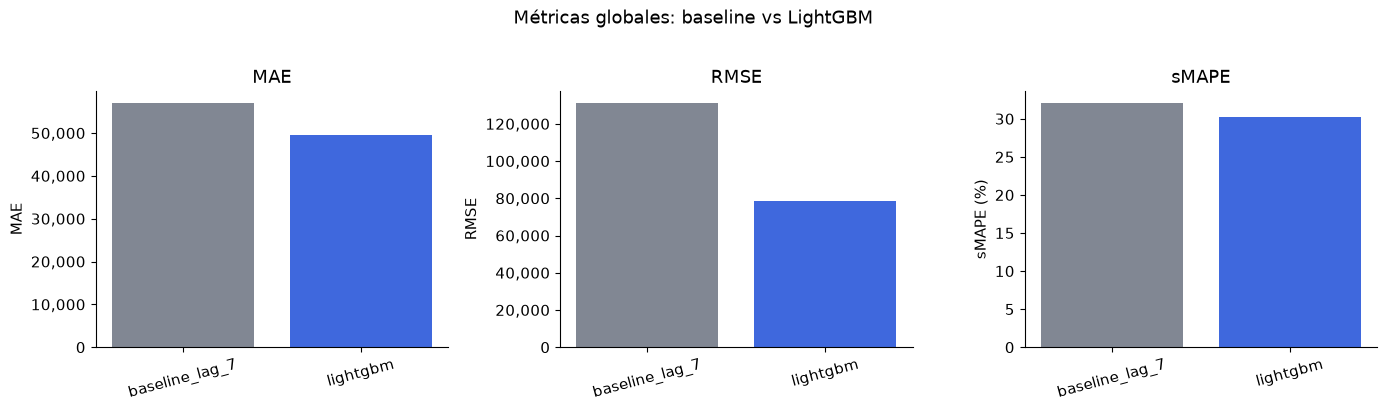

LightGBM mejora sobre la línea base en todas las métricas evaluadas. La mejora más pronunciada se observa en RMSE (40.17%), lo que indica una reducción significativa de los errores de mayor magnitud. El MAE mejora 13.18% y el sMAPE mejora 5.54%.

In [7]:
b = mm["metrics_by_model"]["baseline_lag_7"]
l = mm["metrics_by_model"]["lightgbm"]

# Full metrics table
metrics_df = pd.DataFrame([
    {"Modelo": "baseline_lag_7",
     "MAE": fmt_num(b["mae"]), "RMSE": fmt_num(b["rmse"]),
     "sMAPE": fmt_pct(b["smape"] / 100), "MAE relativo": fmt_pct(b["relative_mae"])},
    {"Modelo": "lightgbm",
     "MAE": fmt_num(l["mae"]), "RMSE": fmt_num(l["rmse"]),
     "sMAPE": fmt_pct(l["smape"] / 100), "MAE relativo": fmt_pct(l["relative_mae"])},
])
display(metrics_df.set_index("Modelo"))

display(Markdown(
    "**Nota:** Las métricas globales se leen desde `model_metrics.json`, generado por el mismo nodo de modelado "
    "que también produce `model_comparison.csv`. Ambos artefactos contienen la misma comparación global "
    "entre `baseline_lag_7` y LightGBM."
))

# Improvement comparison table
comp = pd.DataFrame([
    ("MAE",          fmt_num(b["mae"]),        fmt_num(l["mae"]),        fmt_num(b["mae"] - l["mae"]),          fmt_pct(safe_div(b["mae"]          - l["mae"],          b["mae"]))),
    ("RMSE",         fmt_num(b["rmse"]),       fmt_num(l["rmse"]),       fmt_num(b["rmse"] - l["rmse"]),        fmt_pct(safe_div(b["rmse"]         - l["rmse"],         b["rmse"]))),
    ("sMAPE",        fmt_pct(b["smape"]/100),  fmt_pct(l["smape"]/100),  fmt_pct((b["smape"]-l["smape"])/100),  fmt_pct(safe_div(b["smape"]        - l["smape"],        b["smape"]))),
    ("MAE relativo", fmt_pct(b["relative_mae"]),fmt_pct(l["relative_mae"]),fmt_pct(b["relative_mae"]-l["relative_mae"]),fmt_pct(safe_div(b["relative_mae"]-l["relative_mae"],b["relative_mae"]))),
], columns=["Métrica", "Baseline", "LightGBM", "Cambio absoluto", "Mejora relativa %"])
print("\nComparación de métricas:")
display(comp.set_index("Métrica"))

# Bar charts
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
models = ["baseline_lag_7", "lightgbm"]
colors = ["#6B7280", "#1D4ED8"]

for ax, (metric, vals, ylabel) in zip(axes, [
    ("MAE",   [b["mae"],   l["mae"]],   "MAE"),
    ("RMSE",  [b["rmse"],  l["rmse"]],  "RMSE"),
    ("sMAPE", [b["smape"], l["smape"]], "sMAPE (%)"),
]):
    ax.bar(models, vals, color=colors, alpha=0.85)
    ax.set_title(metric)
    ax.set_ylabel(ylabel)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("Métricas globales: baseline vs LightGBM", y=1.02)
plt.tight_layout()
plt.show()

mae_impr  = safe_div(b["mae"]  - l["mae"],  b["mae"])  * 100
rmse_impr = safe_div(b["rmse"] - l["rmse"], b["rmse"]) * 100
display(Markdown(
    f"LightGBM mejora sobre la línea base en todas las métricas evaluadas. "
    f"La mejora más pronunciada se observa en RMSE ({rmse_impr:.2f}%), lo que indica "
    f"una reducción significativa de los errores de mayor magnitud. "
    f"El MAE mejora {mae_impr:.2f}% y el sMAPE mejora {safe_div(b['smape']-l['smape'],b['smape'])*100:.2f}%."
))

---
## 5. Métricas por Segmento

### Segmento: `category`

,Registros,MAE Baseline,MAE LightGBM,Mejora MAE %,RMSE Baseline,RMSE LightGBM,Mejora RMSE %,sMAPE Baseline,sMAPE LightGBM,Mejora sMAPE %
Segmento,,,,,,,,,,
Abarrotes,"4,797","87,147.17","72,471.55",16.84%,"191,545.88","112,355.51",41.34%,32.70%,29.57%,9.58%
Hogar,"4,797","58,228.20","50,034.70",14.07%,"130,452.32","77,724.00",40.42%,32.06%,29.93%,6.65%
Electronica,"4,797","61,028.43","53,322.12",12.63%,"136,934.57","82,262.44",39.93%,31.57%,29.78%,5.68%
Ropa,"4,797","54,681.82","47,787.34",12.61%,"118,599.55","72,070.78",39.23%,31.56%,29.68%,5.94%
Cuidado_Personal,"4,797","36,587.28","32,817.71",10.30%,"81,085.98","49,278.57",39.23%,32.47%,31.37%,3.40%
Bebidas,"4,797","43,900.31","40,125.09",8.60%,"99,219.77","61,636.46",37.88%,31.79%,31.17%,1.94%


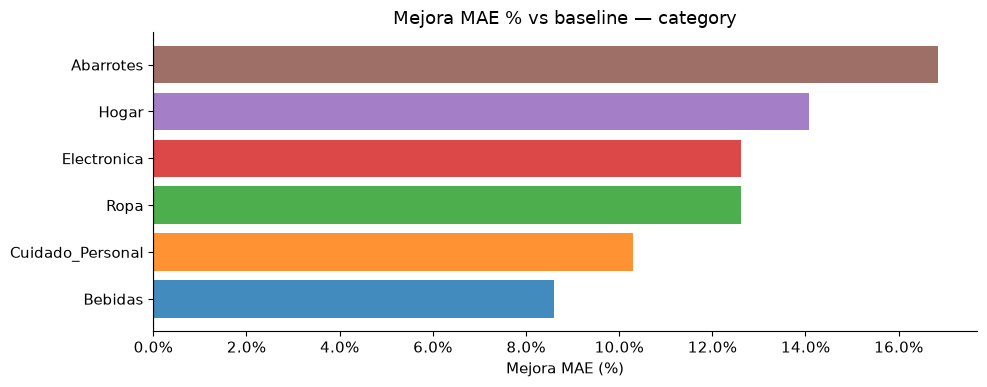

### Segmento: `store_format`

,Registros,MAE Baseline,MAE LightGBM,Mejora MAE %,RMSE Baseline,RMSE LightGBM,Mejora RMSE %,sMAPE Baseline,sMAPE LightGBM,Mejora sMAPE %
Segmento,,,,,,,,,,
Bodega,"12,582","55,452.85","46,871.56",15.47%,"114,173.08","67,052.57",41.27%,31.98%,29.27%,8.47%
Supercenter,"7,200","97,479.73","84,623.95",13.19%,"205,630.01","122,970.59",40.20%,32.25%,30.62%,5.06%
Express,"9,000","26,551.65","24,840.09",6.45%,"53,090.53","35,497.00",33.14%,31.91%,31.33%,1.84%


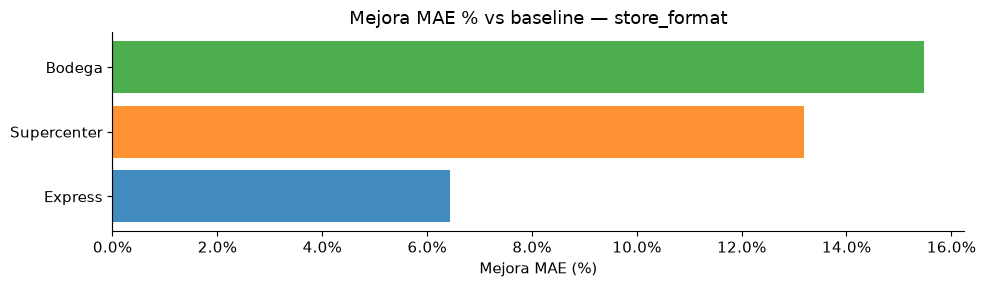

### Segmento: `region`

,Registros,MAE Baseline,MAE LightGBM,Mejora MAE %,RMSE Baseline,RMSE LightGBM,Mejora RMSE %,sMAPE Baseline,sMAPE LightGBM,Mejora sMAPE %
Segmento,,,,,,,,,,
Sur,"4,680","61,666.38","53,155.51",13.80%,"142,898.44","85,302.15",40.31%,32.17%,30.26%,5.95%
Centro,"4,320","57,587.63","49,775.91",13.56%,"127,763.17","76,122.17",40.42%,32.40%,30.12%,7.04%
Occidente,"7,200","58,001.02","50,258.14",13.35%,"138,022.10","83,133.63",39.77%,31.73%,30.04%,5.34%
Norte,"6,102","57,118.17","49,767.96",12.87%,"134,293.90","79,608.65",40.72%,31.60%,30.09%,4.76%
Oriente,"6,480","51,698.61","45,254.43",12.46%,"111,479.00","67,205.70",39.71%,32.40%,30.72%,5.19%


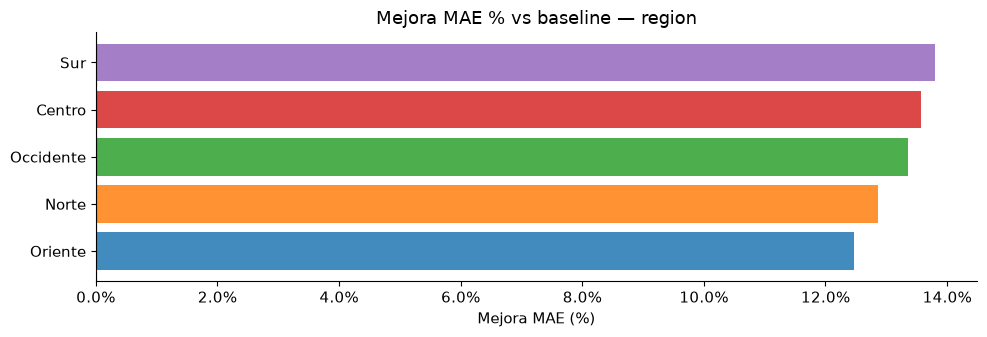

### Segmento: `is_weekend`

,Registros,MAE Baseline,MAE LightGBM,Mejora MAE %,RMSE Baseline,RMSE LightGBM,Mejora RMSE %,sMAPE Baseline,sMAPE LightGBM,Mejora sMAPE %
Segmento,,,,,,,,,,
True,"7,674","83,696.80","63,402.46",24.25%,"199,266.15","96,532.26",51.56%,30.36%,28.86%,4.96%
False,"21,108","47,197.15","44,345.30",6.04%,"94,653.14","70,622.30",25.39%,32.63%,30.76%,5.74%


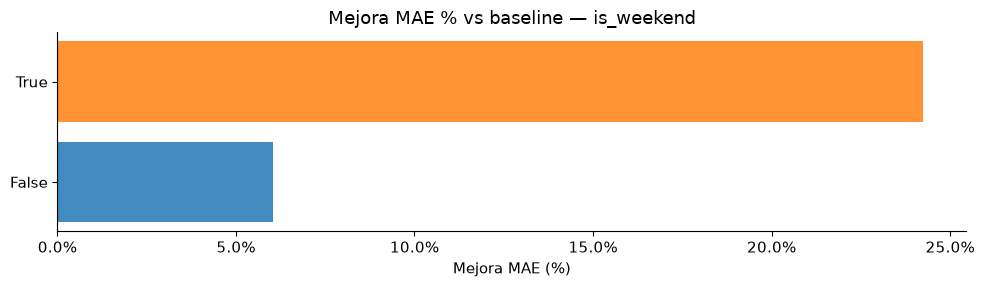

### Segmento: `is_payday`

,Registros,MAE Baseline,MAE LightGBM,Mejora MAE %,RMSE Baseline,RMSE LightGBM,Mejora RMSE %,sMAPE Baseline,sMAPE LightGBM,Mejora sMAPE %
Segmento,,,,,,,,,,
True,"1,920","47,846.80","36,064.79",24.62%,"68,581.14","50,581.61",26.25%,33.73%,22.21%,34.15%
False,"26,862","57,578.02","50,381.46",12.50%,"134,341.02","79,990.04",40.46%,31.90%,30.83%,3.38%


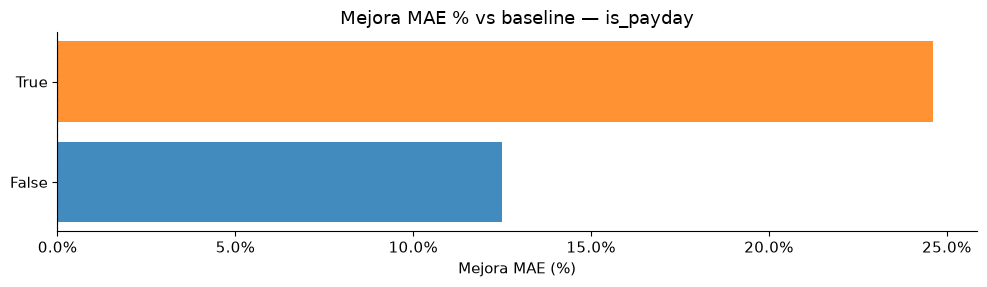

### Segmento: `is_navidad_season`

,Registros,MAE Baseline,MAE LightGBM,Mejora MAE %,RMSE Baseline,RMSE LightGBM,Mejora RMSE %,sMAPE Baseline,sMAPE LightGBM,Mejora sMAPE %
Segmento,,,,,,,,,,
True,"2,880","158,302.90","123,535.82",21.96%,"238,600.78","154,780.51",35.13%,72.60%,71.04%,2.15%
False,"25,902","45,657.26","41,186.32",9.79%,"112,849.69","64,509.38",42.84%,27.51%,25.72%,6.54%


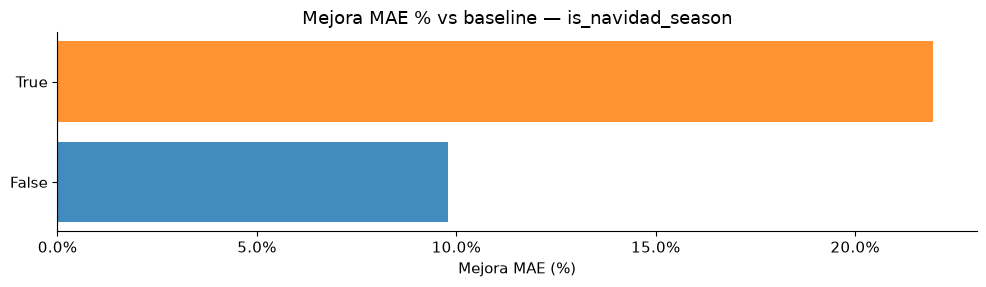

### Segmento: `is_buen_fin`

> **Nota:** El segmento `is_buen_fin = True` no tiene observaciones en el período de prueba (enero–febrero 2024). Solo se evalúa el segmento `False`.

,Registros,MAE Baseline,MAE LightGBM,Mejora MAE %,RMSE Baseline,RMSE LightGBM,Mejora RMSE %,sMAPE Baseline,sMAPE LightGBM,Mejora sMAPE %
Segmento,,,,,,,,,,
False,"28,782","56,928.87","49,426.42",13.18%,"130,986.04","78,372.53",40.17%,32.03%,30.25%,5.54%


### Segmento: `is_semana_santa`

> **Nota:** El segmento `is_semana_santa = True` no tiene observaciones en el período de prueba (enero–febrero 2024). Solo se evalúa el segmento `False`.

,Registros,MAE Baseline,MAE LightGBM,Mejora MAE %,RMSE Baseline,RMSE LightGBM,Mejora RMSE %,sMAPE Baseline,sMAPE LightGBM,Mejora sMAPE %
Segmento,,,,,,,,,,
False,"28,782","56,928.87","49,426.42",13.18%,"130,986.04","78,372.53",40.17%,32.03%,30.25%,5.54%


Los valores negativos de mejora indican segmentos donde la línea base supera al modelo LightGBM. Esto puede indicar una oportunidad de mejora específica para ese segmento.

In [8]:
SEGMENT_COLS = [
    "category", "store_format", "region",
    "is_weekend", "is_payday", "is_navidad_season",
    "is_buen_fin", "is_semana_santa",
]
EVENT_SEGMENTS_NO_TRUE = {"is_buen_fin", "is_semana_santa"}

for seg_col in SEGMENT_COLS:
    display(Markdown(f"### Segmento: `{seg_col}`"))

    pivot = _pivot_segment(segment_metrics, seg_col)

    if seg_col in EVENT_SEGMENTS_NO_TRUE:
        true_present = "True" in pivot["segment_value"].values
        if not true_present:
            display(Markdown(
                f"> **Nota:** El segmento `{seg_col} = True` no tiene observaciones en el período de prueba "
                f"(enero–febrero 2024). Solo se evalúa el segmento `False`."
            ))

    # Build display table
    disp = pivot[["segment_value", "b_n_rows",
                   "b_mae", "l_mae", "mae_impr_pct",
                   "b_rmse", "l_rmse", "rmse_impr_pct",
                   "b_smape", "l_smape", "smape_impr_pct"]].copy()

    disp["b_n_rows"]       = disp["b_n_rows"].apply(lambda v: f"{int(v):,}")
    disp["b_mae"]          = disp["b_mae"].apply(fmt_num)
    disp["l_mae"]          = disp["l_mae"].apply(fmt_num)
    disp["mae_impr_pct"]   = disp["mae_impr_pct"].apply(lambda v: f"{v:.2f}%")
    disp["b_rmse"]         = disp["b_rmse"].apply(fmt_num)
    disp["l_rmse"]         = disp["l_rmse"].apply(fmt_num)
    disp["rmse_impr_pct"]  = disp["rmse_impr_pct"].apply(lambda v: f"{v:.2f}%")
    disp["b_smape"]        = disp["b_smape"].apply(lambda v: f"{v:.2f}%")
    disp["l_smape"]        = disp["l_smape"].apply(lambda v: f"{v:.2f}%")
    disp["smape_impr_pct"] = disp["smape_impr_pct"].apply(lambda v: f"{v:.2f}%")

    disp.columns = [
        "Segmento", "Registros",
        "MAE Baseline", "MAE LightGBM", "Mejora MAE %",
        "RMSE Baseline", "RMSE LightGBM", "Mejora RMSE %",
        "sMAPE Baseline", "sMAPE LightGBM", "Mejora sMAPE %",
    ]
    display(disp.set_index("Segmento"))

    # Horizontal bar chart (only if more than 1 row)
    if len(pivot) > 1:
        chart_data = pivot.sort_values("mae_impr_pct")
        cmap = plt.colormaps["tab10"]
        bar_colors = [cmap(i % 10) for i in range(len(chart_data))]
        fig, ax = plt.subplots(figsize=(10, max(3, len(chart_data) * 0.5 + 1)))
        ax.barh(chart_data["segment_value"].astype(str), chart_data["mae_impr_pct"],
                color=bar_colors, alpha=0.85)
        ax.set_title(f"Mejora MAE % vs baseline — {seg_col}")
        ax.set_xlabel("Mejora MAE (%)")
        ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
        plt.tight_layout()
        plt.show()

display(Markdown(
    "Los valores negativos de mejora indican segmentos donde la línea base supera al modelo LightGBM. "
    "Esto puede indicar una oportunidad de mejora específica para ese segmento."
))

---
## 6. Análisis de Errores

### 6A. Distribución del error

In [9]:
tp = test_predictions

err_stats = pd.DataFrame([
    {
        "Modelo": "baseline_lag_7",
        "Error medio":             fmt_num(tp["baseline_lag_7_error"].mean()),
        "Error mediano":           fmt_num(tp["baseline_lag_7_error"].median()),
        "MAE (error abs medio)":   fmt_num(tp["baseline_lag_7_abs_error"].mean()),
        "MAE mediano":             fmt_num(tp["baseline_lag_7_abs_error"].median()),
        "P90 error abs":           fmt_num(tp["baseline_lag_7_abs_error"].quantile(0.9)),
        "P95 error abs":           fmt_num(tp["baseline_lag_7_abs_error"].quantile(0.95)),
        "Max error abs":           fmt_num(tp["baseline_lag_7_abs_error"].max()),
    },
    {
        "Modelo": "lightgbm",
        "Error medio":             fmt_num(tp["lightgbm_error"].mean()),
        "Error mediano":           fmt_num(tp["lightgbm_error"].median()),
        "MAE (error abs medio)":   fmt_num(tp["lightgbm_abs_error"].mean()),
        "MAE mediano":             fmt_num(tp["lightgbm_abs_error"].median()),
        "P90 error abs":           fmt_num(tp["lightgbm_abs_error"].quantile(0.9)),
        "P95 error abs":           fmt_num(tp["lightgbm_abs_error"].quantile(0.95)),
        "Max error abs":           fmt_num(tp["lightgbm_abs_error"].max()),
    },
])
display(err_stats.set_index("Modelo"))

display(Markdown(
    "LightGBM reduce el error absoluto promedio (MAE) y el máximo vs la línea base. "
    "El error mediano de LightGBM es ligeramente mayor que el de la línea base, lo que sugiere que "
    "el modelo reduce los errores extremos (mejora en P95 y máximo) pero no necesariamente el error "
    "típico de baja magnitud. El error medio positivo en ambos modelos indica una tendencia a sobreestimar en el período de prueba. "
    "Esta desviación podría estar asociada con efectos de calendario o cambios de nivel posteriores a la "
    "temporada navideña, aunque este notebook no establece una relación causal."
))

,Error medio,Error mediano,MAE (error abs medio),MAE mediano,P90 error abs,P95 error abs,Max error abs
Modelo,,,,,,,
baseline_lag_7,"23,974.78","3,328.23","56,928.87","26,527.15","117,138.25","188,413.43","3,242,115.11"
lightgbm,"36,106.78","19,870.89","49,426.42","28,765.06","119,137.40","164,747.60","967,252.26"


LightGBM reduce el error absoluto promedio (MAE) y el máximo vs la línea base. El error mediano de LightGBM es ligeramente mayor que el de la línea base, lo que sugiere que el modelo reduce los errores extremos (mejora en P95 y máximo) pero no necesariamente el error típico de baja magnitud. El error medio positivo en ambos modelos indica una tendencia a sobreestimar en el período de prueba. Esta desviación podría estar asociada con efectos de calendario o cambios de nivel posteriores a la temporada navideña, aunque este notebook no establece una relación causal.

### 6B. Errores sistemáticos por tienda-categoría

In [10]:
# Aggregate by store-category
grp = test_predictions.groupby(["store_id", "category"]).agg(
    actual_sales          =("y_true",                    "sum"),
    baseline_forecast     =("baseline_lag_7_pred",        "sum"),
    lightgbm_forecast     =("lightgbm_pred",              "sum"),
    baseline_abs_error    =("baseline_lag_7_abs_error",   "sum"),
    lightgbm_abs_error    =("lightgbm_abs_error",         "sum"),
    mean_lightgbm_error   =("lightgbm_error",             "mean"),
    mean_baseline_error   =("baseline_lag_7_error",       "mean"),
).reset_index()

grp["error_reduction"]     = grp["baseline_abs_error"] - grp["lightgbm_abs_error"]
grp["error_reduction_pct"] = grp.apply(
    lambda r: safe_div(r["error_reduction"], r["baseline_abs_error"]), axis=1
)
grp["lightgbm_relative_error"] = grp.apply(
    lambda r: safe_div(r["lightgbm_abs_error"], r["actual_sales"]), axis=1
)

# --- Table A: Top 20 by lightgbm_abs_error (descending) ---
display(Markdown("**Tabla A — Top 20 combinaciones tienda-categoría con mayor error absoluto acumulado (LightGBM)**"))
top_err = grp.nlargest(20, "lightgbm_abs_error")[["store_id", "category", "actual_sales", "lightgbm_forecast", "lightgbm_abs_error", "lightgbm_relative_error"]].copy()
top_err["actual_sales"]            = top_err["actual_sales"].apply(fmt_num)
top_err["lightgbm_forecast"]       = top_err["lightgbm_forecast"].apply(fmt_num)
top_err["lightgbm_abs_error"]      = top_err["lightgbm_abs_error"].apply(fmt_num)
top_err["lightgbm_relative_error"] = top_err["lightgbm_relative_error"].apply(fmt_pct)
top_err.columns = ["Tienda", "Categoría", "Ventas reales", "Pronóstico LightGBM", "Error abs (LightGBM)", "Error relativo"]
display(top_err.reset_index(drop=True))
display(Markdown(
    "Las combinaciones con mayor error absoluto acumulado corresponden generalmente a tiendas de alto volumen. "
    "El error relativo permite distinguir entre error por escala y error por desajuste del modelo."
))

# --- Table B: Top 20 by error_reduction (descending) — best LightGBM vs baseline ---
display(Markdown("**Tabla B — Top 20 combinaciones donde LightGBM reduce más el error vs baseline**"))
top_red = grp.nlargest(20, "error_reduction")[["store_id", "category", "baseline_abs_error", "lightgbm_abs_error", "error_reduction", "error_reduction_pct"]].copy()
top_red["baseline_abs_error"]  = top_red["baseline_abs_error"].apply(fmt_num)
top_red["lightgbm_abs_error"]  = top_red["lightgbm_abs_error"].apply(fmt_num)
top_red["error_reduction"]     = top_red["error_reduction"].apply(fmt_num)
top_red["error_reduction_pct"] = top_red["error_reduction_pct"].apply(fmt_pct)
top_red.columns = ["Tienda", "Categoría", "Error abs Baseline", "Error abs LightGBM", "Reducción", "Reducción %"]
display(top_red.reset_index(drop=True))
display(Markdown(
    "Estas combinaciones representan los casos donde el modelo LightGBM agrega mayor valor frente a la línea base. "
    "Una reducción alta indica que el modelo captura patrones que el lag simple no captura."
))

# --- Table C: Top 20 by error_reduction (ascending) — worst LightGBM vs baseline ---
display(Markdown("**Tabla C — Top 20 combinaciones donde LightGBM tiene mayor degradación vs baseline (peores casos)**"))
top_worst = grp.nsmallest(20, "error_reduction")[["store_id", "category", "baseline_abs_error", "lightgbm_abs_error", "error_reduction", "error_reduction_pct"]].copy()
top_worst["baseline_abs_error"]  = top_worst["baseline_abs_error"].apply(fmt_num)
top_worst["lightgbm_abs_error"]  = top_worst["lightgbm_abs_error"].apply(fmt_num)
top_worst["error_reduction"]     = top_worst["error_reduction"].apply(fmt_num)
top_worst["error_reduction_pct"] = top_worst["error_reduction_pct"].apply(fmt_pct)
top_worst.columns = ["Tienda", "Categoría", "Error abs Baseline", "Error abs LightGBM", "Reducción", "Reducción %"]
display(top_worst.reset_index(drop=True))
display(Markdown(
    "Estos son los casos donde la línea base supera a LightGBM. Los valores negativos de reducción "
    "indican que LightGBM sobreestima o subestima más que el lag simple. "
    "Constituyen candidatos prioritarios para análisis de residuos o modelos específicos por segmento."
))

**Tabla A — Top 20 combinaciones tienda-categoría con mayor error absoluto acumulado (LightGBM)**

,Tienda,Categoría,Ventas reales,Pronóstico LightGBM,Error abs (LightGBM),Error relativo
0,STR_017,Abarrotes,"33,967,444.56","40,705,676.97","10,257,767.68",30.20%
1,STR_001,Abarrotes,"32,641,247.76","39,986,544.58","10,241,971.39",31.38%
2,STR_017,Hogar,"22,938,389.03","28,346,022.19","8,707,690.74",37.96%
3,STR_007,Abarrotes,"25,291,315.11","31,341,871.71","8,687,783.13",34.35%
4,STR_015,Abarrotes,"23,331,553.16","29,850,763.55","8,670,510.16",37.16%
5,STR_011,Abarrotes,"28,721,352.05","34,291,381.98","8,608,022.85",29.97%
6,STR_008,Abarrotes,"25,136,168.54","31,666,183.38","8,491,316.42",33.78%
7,STR_017,Electronica,"25,192,613.18","30,953,045.70","8,484,332.83",33.68%
8,STR_002,Abarrotes,"21,000,359.72","27,075,923.29","8,226,146.01",39.17%
9,STR_018,Abarrotes,"21,131,005.95","27,400,187.69","8,129,579.16",38.47%


Las combinaciones con mayor error absoluto acumulado corresponden generalmente a tiendas de alto volumen. El error relativo permite distinguir entre error por escala y error por desajuste del modelo.

**Tabla B — Top 20 combinaciones donde LightGBM reduce más el error vs baseline**

,Tienda,Categoría,Error abs Baseline,Error abs LightGBM,Reducción,Reducción %
0,STR_001,Abarrotes,"14,491,686.74","10,241,971.39","4,249,715.35",29.33%
1,STR_017,Abarrotes,"13,849,723.30","10,257,767.68","3,591,955.62",25.94%
2,STR_007,Abarrotes,"12,189,004.55","8,687,783.13","3,501,221.42",28.72%
3,STR_001,Electronica,"10,811,949.67","8,046,856.68","2,765,092.99",25.57%
4,STR_003,Abarrotes,"9,610,682.49","6,859,466.01","2,751,216.48",28.63%
5,STR_011,Abarrotes,"11,271,345.56","8,608,022.85","2,663,322.71",23.63%
6,STR_014,Abarrotes,"10,284,860.63","8,044,232.73","2,240,627.90",21.79%
7,STR_018,Abarrotes,"10,228,269.88","8,129,579.16","2,098,690.72",20.52%
8,STR_008,Abarrotes,"10,468,635.07","8,491,316.42","1,977,318.65",18.89%
9,STR_014,Hogar,"8,002,709.22","6,199,391.21","1,803,318.01",22.53%


Estas combinaciones representan los casos donde el modelo LightGBM agrega mayor valor frente a la línea base. Una reducción alta indica que el modelo captura patrones que el lag simple no captura.

**Tabla C — Top 20 combinaciones donde LightGBM tiene mayor degradación vs baseline (peores casos)**

,Tienda,Categoría,Error abs Baseline,Error abs LightGBM,Reducción,Reducción %
0,STR_009,Ropa,"3,146,480.65","3,536,516.83","-390,036.18",-12.40%
1,STR_001,Bebidas,"5,430,301.44","5,755,864.49","-325,563.05",-6.00%
2,STR_059,Cuidado_Personal,"770,446.84","1,038,267.99","-267,821.15",-34.76%
3,STR_008,Electronica,"6,180,000.65","6,406,480.65","-226,480.00",-3.66%
4,STR_076,Cuidado_Personal,"744,161.39","947,489.32","-203,327.93",-27.32%
5,STR_076,Hogar,"1,085,715.35","1,283,992.30","-198,276.95",-18.26%
6,STR_060,Cuidado_Personal,"669,239.03","861,718.17","-192,479.14",-28.76%
7,STR_076,Bebidas,"936,818.60","1,124,258.07","-187,439.47",-20.01%
8,STR_019,Electronica,"4,185,710.53","4,356,902.04","-171,191.51",-4.09%
9,STR_036,Bebidas,"1,573,953.13","1,729,843.31","-155,890.18",-9.90%


Estos son los casos donde la línea base supera a LightGBM. Los valores negativos de reducción indican que LightGBM sobreestima o subestima más que el lag simple. Constituyen candidatos prioritarios para análisis de residuos o modelos específicos por segmento.

---
## 7. Importancia de Variables

### 7A. Importancia por ganancia — features originales (top 20)

La **ganancia (gain)** mide la contribución acumulada de cada variable a la reducción del objetivo del modelo. Es la métrica de importancia más informativa para interpretación.

,Rank,Feature,Importancia (gain),Importancia %
0,1,amount_total_lag_7,"10,291,710,110,603,264",26.35%
1,2,amount_total_lag_14,"8,200,453,933,225,984",20.99%
2,3,amount_total_rolling_mean_28,"6,465,605,928,591,360",16.55%
3,4,holiday_name,"5,054,547,181,135,872",12.94%
4,5,amount_total_rolling_mean_7,"2,354,285,040,934,912",6.03%
5,6,amount_total_lag_28,"2,153,079,573,712,896",5.51%
6,7,day_of_week,"1,177,722,068,396,032",3.01%
7,8,week_of_year,"894,795,170,959,360",2.29%
8,9,is_buen_fin,"713,517,779,853,312",1.83%
9,10,is_payday,"452,644,942,962,688",1.16%


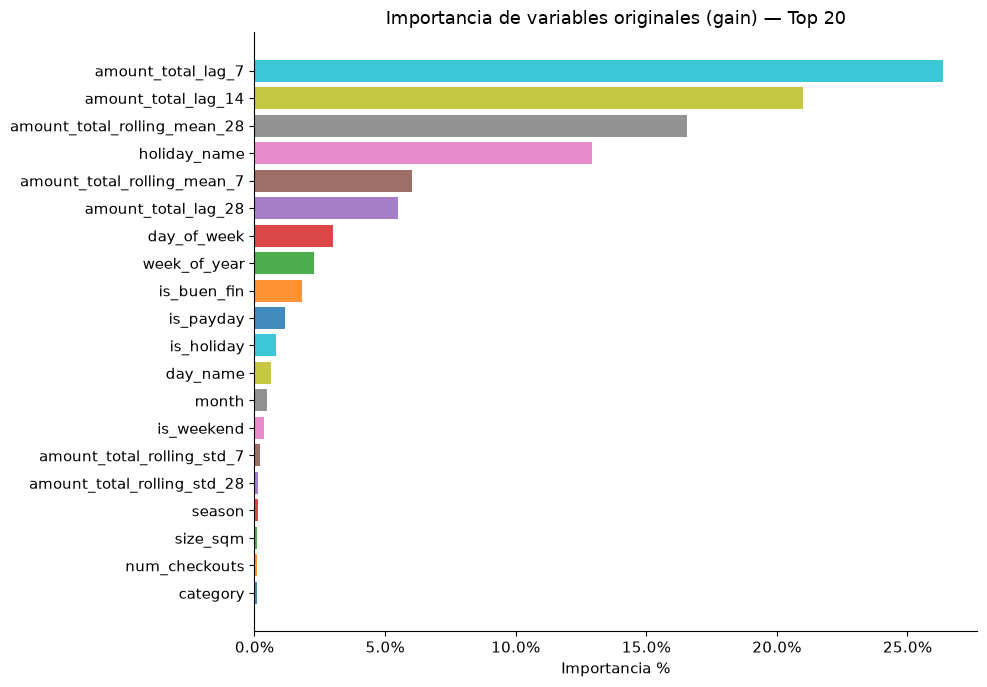

Las features de mayor ganancia son los rezagos y promedios móviles de `amount_total`, lo cual es coherente con un modelo de pronóstico de series de tiempo en retail. `holiday_name` aparece como la variable de contexto más importante, seguida de variables de calendario como `day_of_week` y `week_of_year`. La importancia refleja relevancia predictiva, **no causalidad**.

In [11]:
fi = feature_importance

orig_gain = (fi[(fi["importance_level"]=="original_feature") & (fi["importance_type"]=="gain")]
             .sort_values("rank").head(20).copy())

display_df = orig_gain[["rank","feature","importance","importance_pct"]].copy()
display_df["importance"]     = display_df["importance"].apply(lambda v: fmt_num(v, 0))
display_df["importance_pct"] = display_df["importance_pct"].apply(lambda v: fmt_pct(v))
display_df.columns = ["Rank","Feature","Importancia (gain)","Importancia %"]
display(display_df.reset_index(drop=True))

# Horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 7))
top = orig_gain.sort_values("importance_pct")
colors = [plt.colormaps["tab10"](i % 10) for i in range(len(top))]
ax.barh(top["feature"], top["importance_pct"] * 100, color=colors, alpha=0.85)
ax.set_title("Importancia de variables originales (gain) — Top 20")
ax.set_xlabel("Importancia %")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
plt.tight_layout()
plt.show()

display(Markdown(
    "Las features de mayor ganancia son los rezagos y promedios móviles de `amount_total`, "
    "lo cual es coherente con un modelo de pronóstico de series de tiempo en retail. "
    "`holiday_name` aparece como la variable de contexto más importante, seguida de variables "
    "de calendario como `day_of_week` y `week_of_year`. "
    "La importancia refleja relevancia predictiva, **no causalidad**."
))

### 7B. Importancia por ganancia — features codificadas (top 20)

Las features codificadas muestran niveles específicos de variables categóricas tras el preprocesamiento (OneHotEncoder). La importancia original agrupa estos niveles de vuelta a su variable fuente.

In [12]:
enc_gain = (fi[(fi["importance_level"]=="encoded_feature") & (fi["importance_type"]=="gain")]
            .sort_values("rank").head(20).copy())

display_df = enc_gain[["rank","feature","original_feature","importance","importance_pct"]].copy()
display_df["importance"]     = display_df["importance"].apply(lambda v: fmt_num(v, 0))
display_df["importance_pct"] = display_df["importance_pct"].apply(lambda v: fmt_pct(v))
display_df.columns = ["Rank","Feature codificada","Feature original","Importancia (gain)","Importancia %"]
display(display_df.reset_index(drop=True))

,Rank,Feature codificada,Feature original,Importancia (gain),Importancia %
0,1,num__amount_total_lag_7,amount_total_lag_7,"10,291,710,110,603,264",26.35%
1,2,num__amount_total_lag_14,amount_total_lag_14,"8,200,453,933,225,984",20.99%
2,3,num__amount_total_rolling_mean_28,amount_total_rolling_mean_28,"6,465,605,928,591,360",16.55%
3,4,cat__holiday_name_missing,holiday_name,"3,821,582,808,141,824",9.78%
4,5,num__amount_total_rolling_mean_7,amount_total_rolling_mean_7,"2,354,285,040,934,912",6.03%
5,6,num__amount_total_lag_28,amount_total_lag_28,"2,153,079,573,712,896",5.51%
6,7,num__day_of_week,day_of_week,"1,177,722,068,396,032",3.01%
7,8,num__week_of_year,week_of_year,"894,795,170,959,360",2.29%
8,9,num__is_buen_fin,is_buen_fin,"713,517,779,853,312",1.83%
9,10,cat__holiday_name_Buen Fin,holiday_name,"669,803,216,128,000",1.71%


### 7C. Split vs Gain — top 20 features originales

**Split** mide con qué frecuencia se usa una variable para dividir nodos. **Gain** mide la reducción acumulada del objetivo. Gain es generalmente más informativo para interpretación.

In [13]:
orig_split = (fi[(fi["importance_level"]=="original_feature") & (fi["importance_type"]=="split")]
              .sort_values("rank").head(20).set_index("feature")[["importance_pct","rank"]]
              .rename(columns={"importance_pct":"split_pct","rank":"split_rank"}))

orig_gain_cmp = (fi[(fi["importance_level"]=="original_feature") & (fi["importance_type"]=="gain")]
                 .sort_values("rank").head(20).set_index("feature")[["importance_pct","rank"]]
                 .rename(columns={"importance_pct":"gain_pct","rank":"gain_rank"}))

cmp = orig_gain_cmp.join(orig_split, how="outer").fillna(0).reset_index()
cmp = cmp.sort_values("gain_rank").head(20)
cmp["gain_pct_fmt"]  = cmp["gain_pct"].apply(fmt_pct)
cmp["split_pct_fmt"] = cmp["split_pct"].apply(fmt_pct)
cmp["gain_rank"]  = cmp["gain_rank"].astype(int)
cmp["split_rank"] = cmp["split_rank"].apply(lambda v: int(v) if v > 0 else "—")

display(cmp[["feature","gain_rank","gain_pct_fmt","split_rank","split_pct_fmt"]]
        .rename(columns={"feature":"Feature","gain_rank":"Rank (gain)","gain_pct_fmt":"Importancia gain %",
                         "split_rank":"Rank (split)","split_pct_fmt":"Importancia split %"})
        .reset_index(drop=True))

display(Markdown(
    "Variables de alta ganancia pero menor frecuencia de split (como `holiday_name`) sugieren "
    "que cuando se usan, generan splits de alta reducción del error. "
    "Variables de alta frecuencia de split pero menor ganancia pueden usarse como refinamiento "
    "fino en nodos hoja sin contribuir significativamente al objetivo global."
))

,Feature,Rank (gain),Importancia gain %,Rank (split),Importancia split %
0,opening_year,0,0.00%,19,1.18%
1,store_id,0,0.00%,15,2.00%
2,amount_total_lag_7,1,26.35%,4,8.34%
3,amount_total_lag_14,2,20.99%,3,9.14%
4,amount_total_rolling_mean_28,3,16.55%,1,14.13%
5,holiday_name,4,12.94%,2,10.18%
6,amount_total_rolling_mean_7,5,6.03%,6,5.73%
7,amount_total_lag_28,6,5.51%,5,7.26%
8,day_of_week,7,3.01%,8,5.10%
9,week_of_year,8,2.29%,7,5.64%


Variables de alta ganancia pero menor frecuencia de split (como `holiday_name`) sugieren que cuando se usan, generan splits de alta reducción del error. Variables de alta frecuencia de split pero menor ganancia pueden usarse como refinamiento fino en nodos hoja sin contribuir significativamente al objetivo global.

---
## 8. Verificación de Leakage en Feature Importance

In [14]:
leakage_cols = parameters.get("forecasting", {}).get("leakage_columns", [])
orig_feats = (
    fi[
        (fi["importance_level"] == "original_feature")
        & (fi["importance_type"] == "gain")
    ]
    .set_index("feature")
)

rows = []
for col in leakage_cols:
    if col in orig_feats.index:
        row = orig_feats.loc[col]
        rows.append({"Feature de riesgo": col, "En importancia": "SÍ ⚠️",
                     "Rank (gain)": int(row.get("rank", -1)),
                     "Importancia %": fmt_pct(row.get("importance_pct", 0))})
    else:
        rows.append({"Feature de riesgo": col, "En importancia": "No ✓",
                     "Rank (gain)": "—", "Importancia %": "—"})

leakage_check = pd.DataFrame(rows)
display(leakage_check.set_index("Feature de riesgo"))

any_leakage = any("SÍ" in r["En importancia"] for r in rows)
if any_leakage:
    display(Markdown("⚠️ **Atención:** Alguna variable de riesgo aparece en la importancia del modelo. Revisar el pipeline de features."))
else:
    display(Markdown(
        "✓ Ninguna variable con riesgo de leakage aparece en la importancia del modelo. "
        "El output de feature importance es consistente con la estrategia de prevención de leakage definida en el pipeline."
    ))

,En importancia,Rank (gain),Importancia %
Feature de riesgo,,,
amount_cash,No ✓,—,—
amount_card,No ✓,—,—
total_transactions,No ✓,—,—
cash_transactions,No ✓,—,—
card_transactions,No ✓,—,—
units_sold,No ✓,—,—
avg_ticket,No ✓,—,—
replenishment_signal,No ✓,—,—


✓ Ninguna variable con riesgo de leakage aparece en la importancia del modelo. El output de feature importance es consistente con la estrategia de prevención de leakage definida en el pipeline.

---
## 9. Limitaciones Técnicas y Trabajo Futuro

- **Historia limitada**: ~14 meses disponibles (enero 2023 – febrero 2024).
- **Período de prueba corto**: 60 días (enero–febrero 2024). No incluye Buen Fin ni Semana Santa.
- **Sin cross-validation ni tuning**: hiperparámetros fijos conservadores por restricciones de historia y eventos anuales únicos.
- **Modelo global**: un solo LightGBM sobre todas las series. No hay modelos por tienda, categoría ni cluster.
- **Sin features externas**: no se incluyen precio, inventario, stockouts, margen, campaña ni variables macroeconómicas.
- **La importancia de variables no es causalidad**: indica relevancia predictiva dentro del modelo entrenado.

**Trabajo futuro:**

- Validar con horizonte más largo cuando se disponga de más historia, idealmente cubriendo dos ciclos de Buen Fin.
- Comparar LightGBM con XGBoost y CatBoost bajo un diseño de validación temporal apropiado.
- Explorar modelos específicos por segmento (formato, región o categoría) para los casos con mayor error residual.
- Incorporar features de precio, margen, inventario, stockouts y campaña si los datos están disponibles.
- Implementar reentrenamiento periódico con nuevos datos de transacciones.

---
## 10. Conclusión Técnica

- **LightGBM mejora sobre la línea base semanal** en todas las métricas globales (MAE, RMSE, sMAPE, MAE relativo).
- **La estrategia de validación es temporal** y evita leakage aleatorio de información futura.
- **Las variables con riesgo de leakage fueron excluidas** del modelado; el output de importancia de variables confirma que no aparecen como predictores.
- **La importancia de variables es coherente** con la lógica de pronóstico retail: historial reciente (lags, rolling), variables de calendario y eventos, y contexto de tienda/categoría.
- **El análisis por segmento y errores** identifica dónde el modelo agrega más valor y dónde requiere refinamiento.
- La solución es una **baseline de pronóstico reproducible** construida sobre Kedro, lista para iterar con datos operativos más ricos.